This first cell import core python libraries that i will be utilizing to explore this data.

-pandas and numpy for data handing and some computations.
-matplotlib and seaborn for visualization.
-scikit-learn might come in handy as well.

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing

Initally formating the data to see what it looks like. 

-This file used semi-colons instread of camas so the use of "delimiter=" is needed
-Some rows has too many or too few columns which generated an error so "on_bad_lines='skip" was needed

Data Information 
    -Signature = the type of event. (They all say "Syslog: syslog entry")
    -Data = a timestamp of the syslog events
    -Shape = 2,237 rows with 6 colums


In [87]:
cis = pd.read_csv(
	r"c:\Users\amira\Downloads\ICS_ADD_dataset\OSSIM_Events.csv",
	delimiter=';',
	on_bad_lines='skip'  # skips lines with too many/few fields
)
cis

,Signature,Date,Sensor,Source,Destination,Risk
0,Syslog: syslog entry,2024-02-19 12:16:16,alienvault,0.0.0.0,0.0.0.0,0
1,Syslog: syslog entry,2024-02-19 12:16:16,alienvault,0.0.0.0,0.0.0.0,0
2,Syslog: syslog entry,2024-02-19 12:16:19,alienvault,0.0.0.0,0.0.0.0,0
3,Syslog: syslog entry,2024-02-19 12:16:20,alienvault,0.0.0.0,0.0.0.0,0
4,Syslog: syslog entry,2024-02-19 12:16:21,alienvault,0.0.0.0,0.0.0.0,0
...,...,...,...,...,...,...
2232,Syslog: syslog entry,2024-02-19 12:24:56,alienvault,0.0.0.0,0.0.0.0,0
2233,Syslog: syslog entry,2024-02-19 12:24:56,alienvault,0.0.0.0,0.0.0.0,0
2234,Syslog: syslog entry,2024-02-19 12:24:56,alienvault,0.0.0.0,0.0.0.0,0
2235,Syslog: syslog entry,2024-02-19 12:24:57,alienvault,0.0.0.0,0.0.0.0,0


seeing if any colum Has differing values or if source/destination ever change from 0.0.0.0

In [88]:
for col in cis.columns:
    print(f"{col}: {cis[col].nunique()} unique values")

Signature: 1 unique values
Date: 297 unique values
Sensor: 1 unique values
Source: 2 unique values
Destination: 1 unique values
Risk: 1 unique values


Turns out that source did have 2 values. Now i am wanting to see what values they are and how many times they occur. 

    -'alienvault' occured 90 times and was the other datatype in the source column. i am not sure if this is an error or if this actually means something

In [89]:

print("Source value counts:")
print(cis['Source'].value_counts(dropna=False))

# Show sample rows for each Source value so you can inspect the other one(s)
for val in cis['Source'].dropna().unique():
    print('\n==== Sample rows for Source =', val, '====')
    display(cis[cis['Source'] == val].head(5))



Source value counts:
Source
0.0.0.0       2147
alienvault      90
Name: count, dtype: int64

==== Sample rows for Source = 0.0.0.0 ====


,Signature,Date,Sensor,Source,Destination,Risk
0,Syslog: syslog entry,2024-02-19 12:16:16,alienvault,0.0.0.0,0.0.0.0,0
1,Syslog: syslog entry,2024-02-19 12:16:16,alienvault,0.0.0.0,0.0.0.0,0
2,Syslog: syslog entry,2024-02-19 12:16:19,alienvault,0.0.0.0,0.0.0.0,0
3,Syslog: syslog entry,2024-02-19 12:16:20,alienvault,0.0.0.0,0.0.0.0,0
4,Syslog: syslog entry,2024-02-19 12:16:21,alienvault,0.0.0.0,0.0.0.0,0



==== Sample rows for Source = alienvault ====


,Signature,Date,Sensor,Source,Destination,Risk
6,Syslog: syslog entry,2024-02-19 12:16:26,alienvault,alienvault,0.0.0.0,0
236,Syslog: syslog entry,2024-02-19 12:18:01,alienvault,alienvault,0.0.0.0,0
256,Syslog: syslog entry,2024-02-19 12:18:18,alienvault,alienvault,0.0.0.0,0
259,Syslog: syslog entry,2024-02-19 12:18:20,alienvault,alienvault,0.0.0.0,0
260,Syslog: syslog entry,2024-02-19 12:18:20,alienvault,alienvault,0.0.0.0,0


How long a period does this data cover?

In [90]:
cis['Date'] = pd.to_datetime(
    cis['Date'], errors='coerce')

print(cis['Date'].min(), cis['Date'].max())



2024-02-19 12:16:16 2024-02-19 12:24:59


Make a histogram to see time and the number of events at each time
    -events arent evenly spread out, so bursts of activity could mean something.(maybe attacks?)

Text(0.5, 1.0, 'Distribution of Events Over Time')

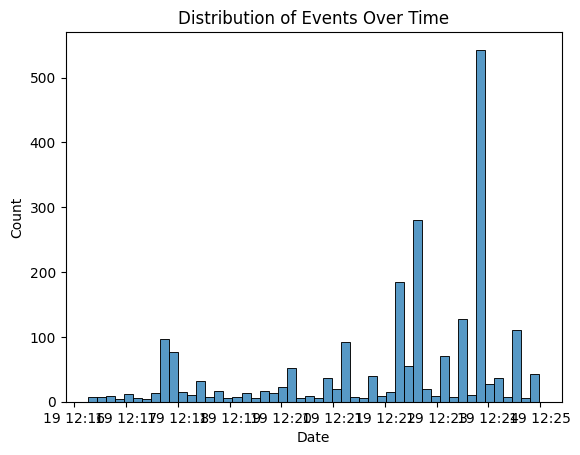

In [91]:
sns.histplot(cis['Date'], bins=50)
plt.title('Distribution of Events Over Time')